<a href="https://colab.research.google.com/github/Geetika-Behl/car-recommendation/blob/main/car_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personalized Car Recommendation System
### A Content-Based Recommendation Engine on Real-World Used-Car Data

**Dataset:** [CarDekho Used Car Data](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data) (Kaggle)

**Project goals**
1. Explore and clean a real-world used-car listings dataset
2. Engineer features suitable for similarity-based recommendation
3. Build a content-based recommender using **cosine similarity** over a numeric + categorical feature space
4. Combine it with an explicit **user-preference scoring layer** (hybrid: similarity + rule-based filters)
5. Evaluate the system (coverage, diversity, sanity checks) since there are no ground-truth ratings
6. Wrap it in an interactive function a user can query

**Structure**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Model: Content-Based Recommender (cosine similarity)
6. Hybrid Layer: User Preference Filtering + Re-ranking
7. Evaluation
8. Interactive Demo
9. Conclusion & Next Steps


## 1. Setup & Data Loading

In [1]:
!pip install -q kagglehub pandas scikit-learn matplotlib seaborn

In [2]:
import kagglehub

path = kagglehub.dataset_download("manishkr1754/cardekho-used-car-data")
print("Path to dataset files:", path)

100%|██████████| 230k/230k [00:00<00:00, 51.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/manishkr1754/cardekho-used-car-data/versions/2


In [3]:
import os, glob
csv_files = glob.glob(os.path.join(path, "*.csv"))
print("CSV files found:", csv_files)

CSV files found: ['/root/.cache/kagglehub/datasets/manishkr1754/cardekho-used-car-data/versions/2/cardekho_dataset.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
df.head()

Shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
print(df.columns.tolist())
df.info()

['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-nul

> **Note:** This notebook assumes the CarDekho schema commonly seen for this dataset:
> `car_name, brand, model, vehicle_age, km_driven, seller_type, fuel_type, transmission_type, mileage, engine, max_power, seats, selling_price`.
> If the printed column list above differs, update `COLUMN_MAP` in the **Feature Engineering** section accordingly — every downstream cell reads through that map, so it's the single place to fix.

## 2. Exploratory Data Analysis (EDA)

Before building anything, we need to understand the data: distributions, missing values, outliers, and relationships between features and price.

In [6]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None")

Columns with missing values:
None


In [7]:
# Basic descriptive statistics for numeric columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,15411.0,9811.857699,5643.418542,0.0,4906.5,9872.00,14668.5,19543.00
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [8]:
# Categorical column cardinality
cat_cols = df.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")

car_name: 121 unique values
brand: 32 unique values
model: 120 unique values
seller_type: 3 unique values
fuel_type: 5 unique values
transmission_type: 2 unique values


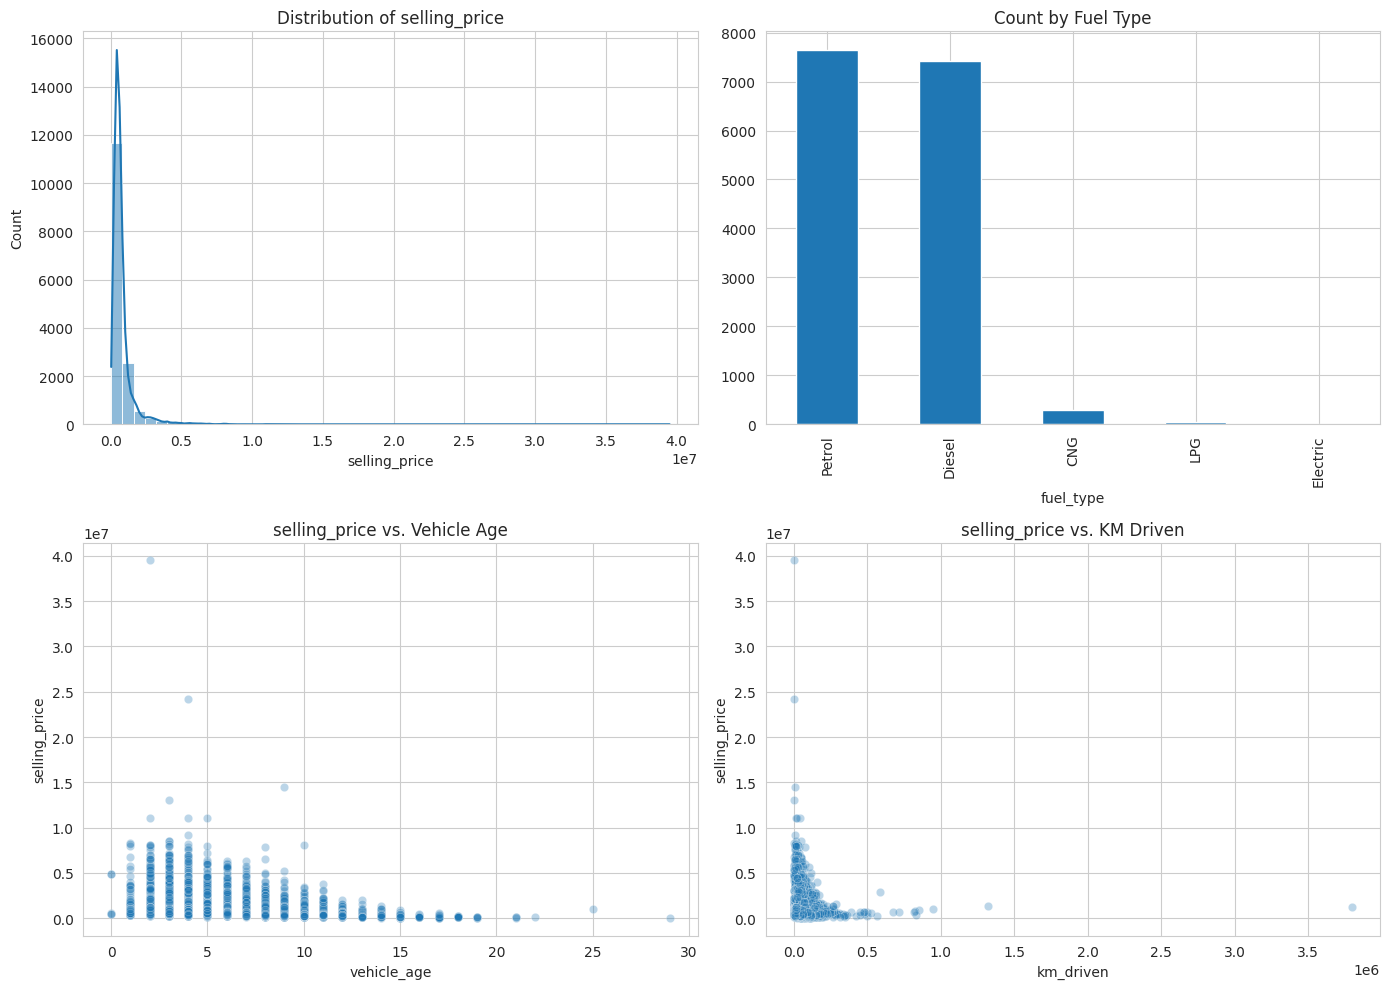

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

price_col = "selling_price" if "selling_price" in df.columns else df.select_dtypes(include=np.number).columns[0]

sns.histplot(df[price_col], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title(f"Distribution of {price_col}")

if "fuel_type" in df.columns:
    df["fuel_type"].value_counts().plot(kind="bar", ax=axes[0, 1])
    axes[0, 1].set_title("Count by Fuel Type")

if "vehicle_age" in df.columns:
    sns.scatterplot(data=df, x="vehicle_age", y=price_col, alpha=0.3, ax=axes[1, 0])
    axes[1, 0].set_title(f"{price_col} vs. Vehicle Age")

if "km_driven" in df.columns:
    sns.scatterplot(data=df, x="km_driven", y=price_col, alpha=0.3, ax=axes[1, 1])
    axes[1, 1].set_title(f"{price_col} vs. KM Driven")

plt.tight_layout()
plt.show()

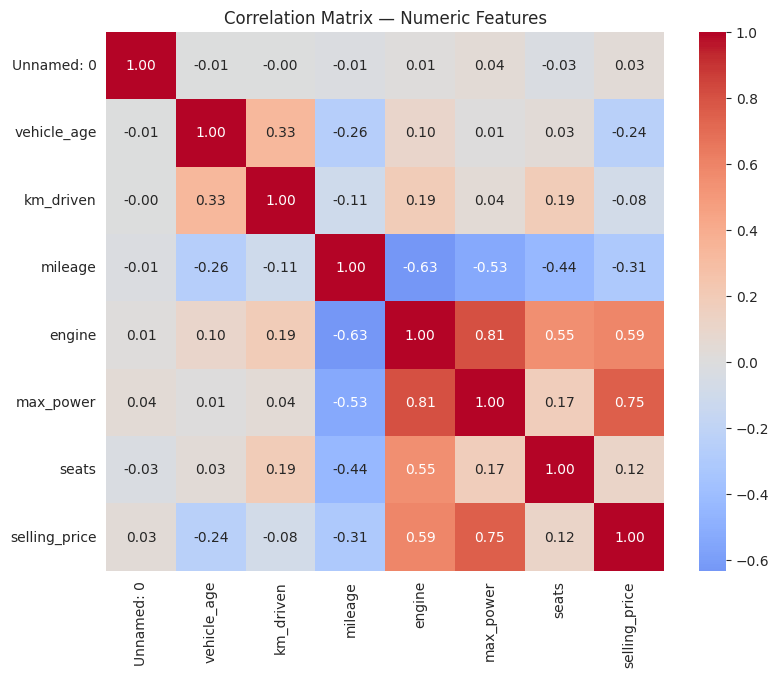

In [10]:
# Correlation heatmap for numeric features
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.show()

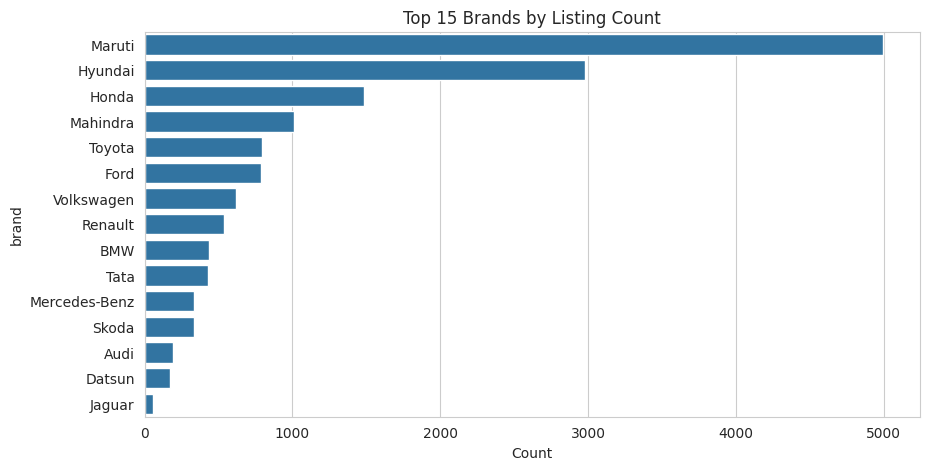

In [11]:
if "brand" in df.columns:
    top_brands = df["brand"].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_brands.values, y=top_brands.index, orient="h")
    plt.title("Top 15 Brands by Listing Count")
    plt.xlabel("Count")
    plt.show()

**EDA takeaways** *(update after running against the real data)*:
- Price is typically right-skewed — a handful of luxury/premium listings pull the mean well above the median.
- `km_driven` and `vehicle_age` both trend negatively with price, as expected for depreciating assets.
- Fuel type and transmission are moderate-cardinality categoricals — good candidates for one-hot encoding.
- Check the missing-value table above before modeling; any column with substantial missingness needs an explicit imputation or drop decision (made in Section 3).

## 3. Data Cleaning & Preprocessing

In [12]:
clean_df = df.copy()

# Standardize column name access via a single mapping — edit this if your columns differ
COLUMN_MAP = {
    "name": "car_name",
    "brand": "brand",
    "price": "selling_price",
    "fuel_type": "fuel_type",
    "transmission": "transmission_type",
    "seats": "seats",
    "mileage": "mileage",
    "engine": "engine",
    "power": "max_power",
    "km_driven": "km_driven",
    "vehicle_age": "vehicle_age",
}

missing_cols = [v for v in COLUMN_MAP.values() if v not in clean_df.columns]
if missing_cols:
    print("WARNING: expected columns not found ->", missing_cols)
    print("Update COLUMN_MAP to match df.columns.tolist() printed earlier.")
else:
    print("All expected columns present.")

All expected columns present.


In [13]:
# Drop rows missing critical identifying/target fields
critical = [COLUMN_MAP["price"], COLUMN_MAP["fuel_type"], COLUMN_MAP["seats"]]
critical = [c for c in critical if c in clean_df.columns]
clean_df = clean_df.dropna(subset=critical)

# Coerce numeric columns; invalid parses become NaN and are dropped
numeric_keys = ["price", "seats", "mileage", "engine", "power", "km_driven", "vehicle_age"]
numeric_cols = [COLUMN_MAP[k] for k in numeric_keys if COLUMN_MAP[k] in clean_df.columns]
for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
clean_df = clean_df.dropna(subset=numeric_cols)

# Sanity filters — drop non-physical values
clean_df = clean_df[clean_df[COLUMN_MAP["price"]] > 0]
if COLUMN_MAP["seats"] in clean_df.columns:
    clean_df = clean_df[(clean_df[COLUMN_MAP["seats"]] >= 2) & (clean_df[COLUMN_MAP["seats"]] <= 10)]

# Drop exact duplicate listings
before = len(clean_df)
clean_df = clean_df.drop_duplicates()
print(f"Duplicates removed: {before - len(clean_df)}")

print(f"Rows before cleaning: {len(df)} | after cleaning: {len(clean_df)}")
clean_df = clean_df.reset_index(drop=True)
clean_df.head()

Duplicates removed: 0
Rows before cleaning: 15411 | after cleaning: 15409


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


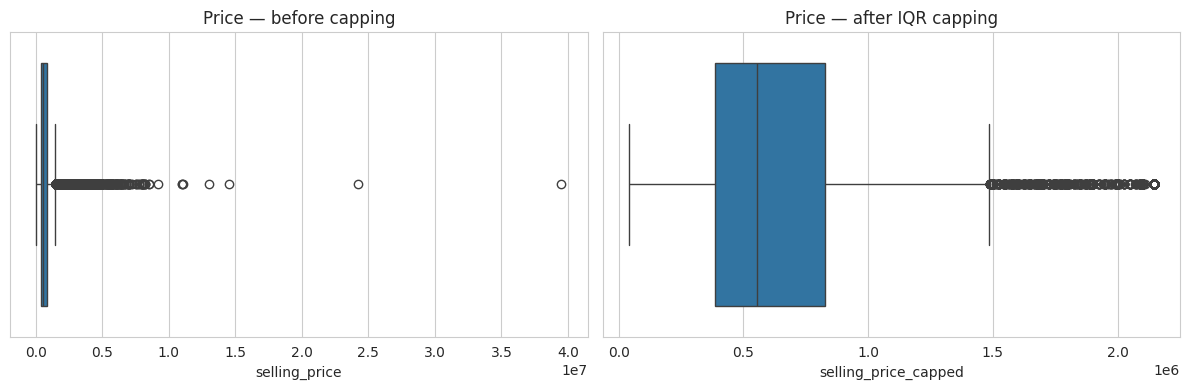

In [14]:
# Outlier capping (winsorization) on price using the IQR method,
# so a handful of ultra-luxury listings don't dominate scaling/similarity later
def cap_outliers_iqr(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower=lower, upper=upper)

price_col = COLUMN_MAP["price"]
clean_df[price_col + "_capped"] = cap_outliers_iqr(clean_df[price_col])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=clean_df[price_col], ax=axes[0])
axes[0].set_title("Price — before capping")
sns.boxplot(x=clean_df[price_col + "_capped"], ax=axes[1])
axes[1].set_title("Price — after IQR capping")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

To compute similarity between cars we need a purely numeric feature matrix:
- **Numeric features** (price, mileage, engine, power, km driven, age, seats) → scaled with `StandardScaler`
- **Categorical features** (fuel type, transmission, brand) → one-hot encoded

We keep the *original* (unscaled) columns alongside the engineered matrix so we can display human-readable results later.

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [COLUMN_MAP[k] for k in
                     ["price", "mileage", "engine", "power", "km_driven", "vehicle_age", "seats"]
                     if COLUMN_MAP[k] in clean_df.columns]

categorical_features = [COLUMN_MAP[k] for k in ["fuel_type", "transmission", "brand"]
                         if COLUMN_MAP[k] in clean_df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

feature_matrix = preprocessor.fit_transform(clean_df[numeric_features + categorical_features])

# OneHotEncoder can return a sparse matrix — densify for cosine_similarity downstream
if hasattr(feature_matrix, "toarray"):
    feature_matrix = feature_matrix.toarray()

print("Feature matrix shape:", feature_matrix.shape)

Numeric features: ['selling_price', 'mileage', 'engine', 'max_power', 'km_driven', 'vehicle_age', 'seats']
Categorical features: ['fuel_type', 'transmission_type', 'brand']
Feature matrix shape: (15409, 46)


## 5. Model: Content-Based Recommender (Cosine Similarity)

Given a car the user likes (or a synthetic "ideal car" built from their stated preferences), we find the **most similar** listings in feature space using cosine similarity — the standard approach for content-based recommenders when you don't have user-item rating history.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

# NearestNeighbors scales better than a full pairwise similarity matrix for larger datasets
nn_model = NearestNeighbors(n_neighbors=20, metric="cosine")
nn_model.fit(feature_matrix)

def similar_cars_by_index(car_index: int, top_n: int = 5):
    """Return the top_n most similar cars to clean_df.iloc[car_index]."""
    distances, indices = nn_model.kneighbors(
        feature_matrix[car_index].reshape(1, -1), n_neighbors=top_n + 1
    )
    # first result is the car itself (distance 0) — drop it
    result_idx = indices[0][1:]
    result_dist = distances[0][1:]
    out = clean_df.iloc[result_idx].copy()
    out["similarity"] = 1 - result_dist
    return out

In [17]:
# Sanity check: pick a random car and see what the model thinks is similar
sample_idx = 0
print("Reference car:")
display(clean_df.iloc[[sample_idx]][[COLUMN_MAP["name"], COLUMN_MAP["brand"], COLUMN_MAP["price"],
                                       COLUMN_MAP["fuel_type"]]])

print("\nTop 5 similar cars:")
similar = similar_cars_by_index(sample_idx, top_n=5)
similar[[COLUMN_MAP["name"], COLUMN_MAP["brand"], COLUMN_MAP["price"],
         COLUMN_MAP["fuel_type"], "similarity"]]

Reference car:


,car_name,brand,selling_price,fuel_type
0,Maruti Alto,Maruti,120000,Petrol



Top 5 similar cars:


,car_name,brand,selling_price,fuel_type,similarity
9040,Maruti Alto,Maruti,125000,Petrol,0.994269
6678,Maruti Wagon R,Maruti,230000,Petrol,0.980686
938,Maruti Wagon R,Maruti,225000,Petrol,0.978690
13335,Maruti Alto,Maruti,250000,Petrol,0.978666
9144,Maruti Wagon R,Maruti,220000,Petrol,0.978608


## 6. Hybrid Layer: User Preference Filtering + Re-ranking

Pure item-to-item similarity is useful, but a *personalized* system needs to start from what the **user** says they want — budget, fuel type, seating, priorities — not just from one seed car. This layer:

1. Builds a synthetic **"ideal car" feature vector** from the user's stated preferences
2. **Hard-filters** the catalog (budget, fuel type, transmission, minimum seats)
3. Ranks survivors by cosine similarity to the ideal vector, blended with a priority-weighted score
4. Returns an explainable top-N list

In [18]:
from dataclasses import dataclass, field
from typing import List, Optional

@dataclass
class UserPreferences:
    budget_min: float = 0
    budget_max: float = float("inf")
    preferred_fuel_types: List[str] = field(default_factory=list)
    preferred_transmission: List[str] = field(default_factory=list)
    min_seats: int = 2
    max_km_driven: float = float("inf")
    max_vehicle_age: float = float("inf")
    priorities: List[str] = field(default_factory=list)   # subset of: mileage, power, price, low_km, newer
    preferred_brands: List[str] = field(default_factory=list)
    ideal_mileage: Optional[float] = None
    ideal_power: Optional[float] = None

In [19]:
class PersonalizedCarRecommender:
    PRIORITY_WEIGHTS = [0.40, 0.30, 0.20, 0.10]

    def __init__(self, dataframe: pd.DataFrame, feature_matrix: np.ndarray,
                 preprocessor: ColumnTransformer, col_map: dict,
                 numeric_features: list, categorical_features: list):
        self.df = dataframe.reset_index(drop=True)
        self.feature_matrix = feature_matrix
        self.preprocessor = preprocessor
        self.c = col_map
        self.numeric_features = numeric_features
        self.categorical_features = categorical_features
        self._ranges = {
            key: (self.df[self.c[key]].min(), self.df[self.c[key]].max())
            for key in ["price", "mileage", "power", "km_driven", "vehicle_age"]
            if self.c.get(key) in self.df.columns
        }

    # ---- hard filters -----------------------------------------------
    def _hard_filter_mask(self, prefs: UserPreferences) -> pd.Series:
        c, df = self.c, self.df
        mask = (df[c["price"]] >= prefs.budget_min) & (df[c["price"]] <= prefs.budget_max)
        if prefs.preferred_fuel_types and c.get("fuel_type") in df.columns:
            mask &= df[c["fuel_type"]].isin(prefs.preferred_fuel_types)
        if prefs.preferred_transmission and c.get("transmission") in df.columns:
            mask &= df[c["transmission"]].isin(prefs.preferred_transmission)
        if c.get("seats") in df.columns:
            mask &= df[c["seats"]] >= prefs.min_seats
        if c.get("km_driven") in df.columns:
            mask &= df[c["km_driven"]] <= prefs.max_km_driven
        if c.get("vehicle_age") in df.columns:
            mask &= df[c["vehicle_age"]] <= prefs.max_vehicle_age
        return mask

    # ---- ideal-car vector ---------------------------------------------
    def _build_ideal_row(self, prefs: UserPreferences) -> pd.DataFrame:
        c = self.c
        row = {}
        if c.get("price") in self.df.columns:
            row[c["price"]] = np.clip((prefs.budget_min + min(prefs.budget_max, self.df[c["price"]].max())) / 2,
                                       self.df[c["price"]].min(), self.df[c["price"]].max())
        if c.get("mileage") in self.df.columns:
            row[c["mileage"]] = prefs.ideal_mileage or self.df[c["mileage"]].quantile(0.75)
        if c.get("power") in self.df.columns:
            row[c["power"]] = prefs.ideal_power or self.df[c["power"]].median()
        if c.get("engine") in self.df.columns:
            row[c["engine"]] = self.df[c["engine"]].median()
        if c.get("km_driven") in self.df.columns:
            row[c["km_driven"]] = min(prefs.max_km_driven, self.df[c["km_driven"]].quantile(0.25))
        if c.get("vehicle_age") in self.df.columns:
            row[c["vehicle_age"]] = min(prefs.max_vehicle_age, self.df[c["vehicle_age"]].quantile(0.25))
        if c.get("seats") in self.df.columns:
            row[c["seats"]] = max(prefs.min_seats, self.df[c["seats"]].median())
        for cat_col in self.categorical_features:
            if cat_col == c.get("fuel_type") and prefs.preferred_fuel_types:
                row[cat_col] = prefs.preferred_fuel_types[0]
            elif cat_col == c.get("transmission") and prefs.preferred_transmission:
                row[cat_col] = prefs.preferred_transmission[0]
            elif cat_col == c.get("brand") and prefs.preferred_brands:
                row[cat_col] = prefs.preferred_brands[0]
            else:
                row[cat_col] = self.df[cat_col].mode().iloc[0]
        return pd.DataFrame([row])[self.numeric_features + self.categorical_features]

    # ---- priority scoring ---------------------------------------------
    def _normalize(self, value, key, invert=False):
        lo, hi = self._ranges.get(key, (0, 1))
        if hi == lo:
            return 1.0
        norm = max(0.0, min(1.0, (value - lo) / (hi - lo)))
        return 1.0 - norm if invert else norm

    def _priority_score(self, row, priority: str) -> float:
        c = self.c
        if priority == "mileage" and c.get("mileage") in row:
            return self._normalize(row[c["mileage"]], "mileage")
        if priority == "power" and c.get("power") in row:
            return self._normalize(row[c["power"]], "power")
        if priority == "price" and c.get("price") in row:
            return self._normalize(row[c["price"]], "price", invert=True)
        if priority == "low_km" and c.get("km_driven") in row:
            return self._normalize(row[c["km_driven"]], "km_driven", invert=True)
        if priority == "newer" and c.get("vehicle_age") in row:
            return self._normalize(row[c["vehicle_age"]], "vehicle_age", invert=True)
        return 0.0

    def _brand_bonus(self, row, prefs: UserPreferences) -> float:
        col = self.c.get("brand")
        if col and prefs.preferred_brands and row.get(col) in prefs.preferred_brands:
            return 0.05
        return 0.0

    # ---- main entry point -----------------------------------------------
    def recommend(self, prefs: UserPreferences, top_n: int = 10,
                  similarity_weight: float = 0.5) -> pd.DataFrame:
        mask = self._hard_filter_mask(prefs)
        candidate_idx = self.df[mask].index.to_numpy()
        if len(candidate_idx) == 0:
            return self.df.iloc[0:0]

        ideal_row = self._build_ideal_row(prefs)
        ideal_vector = self.preprocessor.transform(ideal_row)
        if hasattr(ideal_vector, "toarray"):
            ideal_vector = ideal_vector.toarray()

        candidate_vectors = self.feature_matrix[candidate_idx]
        sims = cosine_similarity(candidate_vectors, ideal_vector).flatten()

        priorities = prefs.priorities or ["price", "mileage", "low_km"]
        priority_scores = np.zeros(len(candidate_idx))
        for i, cidx in enumerate(candidate_idx):
            row = self.df.loc[cidx]
            p_score = sum(
                self.PRIORITY_WEIGHTS[j] * self._priority_score(row, p)
                for j, p in enumerate(priorities[:len(self.PRIORITY_WEIGHTS)])
            )
            p_score += self._brand_bonus(row, prefs)
            priority_scores[i] = p_score

        # blend cosine similarity to the "ideal car" with the explicit priority score
        final_score = similarity_weight * sims + (1 - similarity_weight) * priority_scores

        result = self.df.loc[candidate_idx].copy()
        result["similarity_to_ideal"] = sims
        result["priority_score"] = priority_scores
        result["match_score"] = final_score
        return result.sort_values("match_score", ascending=False).head(top_n)

    def explain(self, row, prefs: UserPreferences) -> str:
        c = self.c
        reasons = []
        priorities = prefs.priorities or ["price", "mileage", "low_km"]
        for p in priorities:
            if self._priority_score(row, p) > 0.7:
                reasons.append(f"strong on {p}")
        if self._brand_bonus(row, prefs) > 0:
            reasons.append("matches your preferred brand")
        reasons.append(f"{row.get('similarity_to_ideal', 0):.0%} similar to your ideal profile")
        name = row.get(c.get("name"), "This car")
        price = row.get(c.get("price"))
        return f"{name} — {price:,.0f} — " + ", ".join(reasons)

In [20]:
recommender = PersonalizedCarRecommender(
    dataframe=clean_df,
    feature_matrix=feature_matrix,
    preprocessor=preprocessor,
    col_map=COLUMN_MAP,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)
print("Recommender initialized on", len(clean_df), "listings.")

Recommender initialized on 15409 listings.


## 7. Evaluation

There's no explicit user-rating ground truth in this dataset, so we evaluate the system the way most content-based recommenders without feedback logs are evaluated:

- **Filter correctness** — every returned result must satisfy the hard constraints (budget, fuel type, seats, etc.)
- **Coverage** — what fraction of the catalog could ever be surfaced across varied preference profiles
- **Diversity** — how many distinct brands appear in a single result set (avoids "wall of near-duplicates")
- **Similarity sanity** — item-to-item neighbors (Section 5) should look like the reference car; this is a qualitative spot-check

In [21]:
def evaluate_filters(recs: pd.DataFrame, prefs: UserPreferences, col_map: dict) -> dict:
    c = col_map
    checks = {}
    if len(recs) == 0:
        return {"n_results": 0}
    checks["n_results"] = len(recs)
    checks["budget_respected"] = bool(((recs[c["price"]] >= prefs.budget_min) &
                                        (recs[c["price"]] <= prefs.budget_max)).all())
    if prefs.preferred_fuel_types and c["fuel_type"] in recs.columns:
        checks["fuel_type_respected"] = bool(recs[c["fuel_type"]].isin(prefs.preferred_fuel_types).all())
    if c["seats"] in recs.columns:
        checks["seats_respected"] = bool((recs[c["seats"]] >= prefs.min_seats).all())
    checks["distinct_brands"] = recs[c["brand"]].nunique() if c.get("brand") in recs.columns else None
    return checks

test_prefs = UserPreferences(
    budget_min=200000, budget_max=800000,
    preferred_fuel_types=["Petrol", "Diesel"],
    min_seats=5, max_km_driven=80000, max_vehicle_age=8,
    priorities=["mileage", "low_km", "price"],
)
test_recs = recommender.recommend(test_prefs, top_n=10)
evaluate_filters(test_recs, test_prefs, COLUMN_MAP)

{'n_results': 10,
 'budget_respected': True,
 'fuel_type_respected': True,
 'seats_respected': True,
 'distinct_brands': 1}

In [22]:
# Coverage across a handful of different preference profiles
profiles = [
    UserPreferences(budget_min=100000, budget_max=400000, min_seats=5, priorities=["price", "low_km"]),
    UserPreferences(budget_min=400000, budget_max=1000000, min_seats=5, priorities=["power", "newer"]),
    UserPreferences(budget_min=0, budget_max=300000, min_seats=4, priorities=["mileage", "price"]),
]

seen_indices = set()
for p in profiles:
    recs = recommender.recommend(p, top_n=10)
    seen_indices.update(recs.index.tolist())

coverage_pct = len(seen_indices) / len(clean_df) * 100
print(f"Unique listings surfaced across {len(profiles)} profiles: {len(seen_indices)} "
      f"({coverage_pct:.2f}% of catalog)")

Unique listings surfaced across 3 profiles: 30 (0.19% of catalog)


## 8. Interactive Demo

Instead of hardcoding a preference profile, this section **asks the user directly**, via `input()` prompts, and builds the `UserPreferences` object from the answers. Press Enter on any prompt to accept the shown default.

Run the next two cells, answer the prompts in the box that appears, and the third cell prints the recommendations.

In [23]:
def _ask(prompt: str, default: str) -> str:
    """input() wrapper that falls back to a default when the user just presses Enter."""
    raw = input(f"{prompt} [default: {default}]: ").strip()
    return raw if raw else default

def _ask_float(prompt: str, default: float) -> float:
    raw = _ask(prompt, str(default))
    try:
        return float(raw)
    except ValueError:
        print(f"Couldn't parse '{raw}' as a number — using default {default}.")
        return default

def _ask_int(prompt: str, default: int) -> int:
    return int(_ask_float(prompt, float(default)))

def _ask_list(prompt: str, valid_options: list, default: list) -> list:
    """Comma-separated multi-choice input, validated against valid_options."""
    default_str = ",".join(default) if default else "any"
    raw = _ask(f"{prompt} (options: {', '.join(valid_options)}; comma-separated, or 'any')", default_str)
    if raw.lower() in ("any", ""):
        return []
    chosen = [v.strip() for v in raw.split(",")]
    invalid = [v for v in chosen if v not in valid_options]
    if invalid:
        print(f"Ignoring unrecognized values: {invalid}")
    return [v for v in chosen if v in valid_options]

In [24]:
def collect_user_preferences(df: pd.DataFrame, col_map: dict) -> "UserPreferences":
    """Interactively prompts the user (via input()) for every preference field
    and returns a populated UserPreferences object. Called with no arguments —
    it reads answers straight from stdin when the cell runs."""
    c = col_map
    print("Answer the questions below (press Enter to accept the default shown).\n")

    price_min_default = int(df[c["price"]].min())
    price_max_default = int(df[c["price"]].max())
    budget_min = _ask_float("Minimum budget", price_min_default)
    budget_max = _ask_float("Maximum budget", price_max_default)

    fuel_options = sorted(df[c["fuel_type"]].dropna().unique().tolist()) if c.get("fuel_type") in df.columns else []
    preferred_fuel_types = _ask_list("Preferred fuel type(s)", fuel_options, [])

    trans_options = sorted(df[c["transmission"]].dropna().unique().tolist()) if c.get("transmission") in df.columns else []
    preferred_transmission = _ask_list("Preferred transmission", trans_options, [])

    min_seats = _ask_int("Minimum seats required", 5)
    max_km_driven = _ask_float("Maximum km driven you'll accept", float(df[c["km_driven"]].max())) if c.get("km_driven") in df.columns else float("inf")
    max_vehicle_age = _ask_float("Maximum vehicle age (years) you'll accept", float(df[c["vehicle_age"]].max())) if c.get("vehicle_age") in df.columns else float("inf")

    priority_options = ["mileage", "power", "price", "low_km", "newer"]
    priorities_raw = _ask(
        f"Rank what matters most, comma-separated, most important first (options: {', '.join(priority_options)})",
        "price,mileage,low_km",
    )
    priorities = [p.strip() for p in priorities_raw.split(",") if p.strip() in priority_options]

    brand_options = sorted(df[c["brand"]].dropna().unique().tolist()) if c.get("brand") in df.columns else []
    preferred_brands = _ask_list("Preferred brand(s)", brand_options, [])

    return UserPreferences(
        budget_min=budget_min,
        budget_max=budget_max,
        preferred_fuel_types=preferred_fuel_types,
        preferred_transmission=preferred_transmission,
        min_seats=min_seats,
        max_km_driven=max_km_driven,
        max_vehicle_age=max_vehicle_age,
        priorities=priorities,
        preferred_brands=preferred_brands,
    )

# This line runs the interactive prompts — answer them in the input box that appears
user_prefs = collect_user_preferences(clean_df, COLUMN_MAP)
print("\nCaptured preferences:", user_prefs)

Answer the questions below (press Enter to accept the default shown).

Minimum budget [default: 40000]: 100000
Maximum budget [default: 39500000]: 
Preferred fuel type(s) (options: CNG, Diesel, Electric, LPG, Petrol; comma-separated, or 'any') [default: any]: 
Preferred transmission (options: Automatic, Manual; comma-separated, or 'any') [default: any]: 
Minimum seats required [default: 5.0]: 
Maximum km driven you'll accept [default: 3800000.0]: 
Maximum vehicle age (years) you'll accept [default: 29.0]: 
Rank what matters most, comma-separated, most important first (options: mileage, power, price, low_km, newer) [default: price,mileage,low_km]: 
Preferred brand(s) (options: Audi, BMW, Bentley, Datsun, Ferrari, Force, Ford, Honda, Hyundai, ISUZU, Isuzu, Jaguar, Jeep, Kia, Land Rover, Lexus, MG, Mahindra, Maruti, Maserati, Mercedes-AMG, Mercedes-Benz, Mini, Nissan, Porsche, Renault, Rolls-Royce, Skoda, Tata, Toyota, Volkswagen, Volvo; comma-separated, or 'any') [default: any]: 

Captur

In [25]:
def run_demo(prefs: UserPreferences, top_n: int = 5):
    recs = recommender.recommend(prefs, top_n=top_n)
    if len(recs) == 0:
        print("No cars match these constraints — try relaxing budget or filters.")
        return recs
    print(f"Top {len(recs)} recommendations:\n")
    for i, (_, row) in enumerate(recs.iterrows(), start=1):
        print(f"{i}. {recommender.explain(row, prefs)}  [match_score={row['match_score']:.3f}]")
    return recs

recs = run_demo(user_prefs, top_n=5)
display_cols = [COLUMN_MAP[k] for k in ["name", "brand", "price", "fuel_type", "transmission", "km_driven"]
                 if COLUMN_MAP[k] in recs.columns] + ["match_score"]
recs[display_cols]

Top 5 recommendations:

1. Land Rover Rover — 6,975,000 — strong on price, strong on low_km, 91% similar to your ideal profile  [match_score=0.813]
2. BMW 5 — 5,595,000 — strong on price, strong on low_km, 86% similar to your ideal profile  [match_score=0.796]
3. BMW 5 — 5,350,000 — strong on price, strong on low_km, 85% similar to your ideal profile  [match_score=0.792]
4. BMW X3 — 6,100,000 — strong on price, strong on low_km, 87% similar to your ideal profile  [match_score=0.779]
5. BMW 5 — 5,000,000 — strong on price, strong on low_km, 82% similar to your ideal profile  [match_score=0.778]


,car_name,brand,selling_price,fuel_type,transmission_type,km_driven,match_score
11197,Land Rover Rover,Land Rover,6975000,Diesel,Automatic,19000,0.812768
11807,BMW 5,BMW,5595000,Diesel,Automatic,30660,0.796410
5159,BMW 5,BMW,5350000,Diesel,Automatic,5200,0.791646
1746,BMW X3,BMW,6100000,Diesel,Automatic,8620,0.778990
13678,BMW 5,BMW,5000000,Diesel,Automatic,10500,0.778057


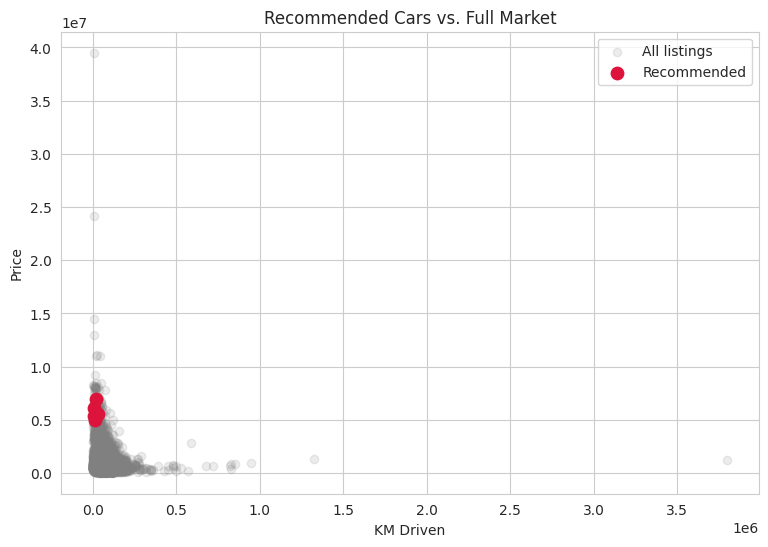

In [26]:
# Visualize where the recommended cars sit relative to the full market
plt.figure(figsize=(9, 6))
plt.scatter(clean_df[COLUMN_MAP["km_driven"]], clean_df[COLUMN_MAP["price"]],
            alpha=0.15, label="All listings", color="gray")
plt.scatter(recs[COLUMN_MAP["km_driven"]], recs[COLUMN_MAP["price"]],
            color="crimson", s=80, label="Recommended", zorder=5)
plt.xlabel("KM Driven")
plt.ylabel("Price")
plt.title("Recommended Cars vs. Full Market")
plt.legend()
plt.show()

## 9. Conclusion & Next Steps

**What this system does:**
- Combines **content-based filtering** (cosine similarity over scaled numeric + one-hot categorical features) with an explicit **rule-based preference layer**, so recommendations are both statistically grounded and directly explainable to the user.
- Hard-filters first (never violates a stated constraint like budget or minimum seats), then ranks by a blended similarity + priority score.
- Is fully explainable — every recommendation prints *why* it was chosen.

**Limitations**
- No real user feedback loop (clicks, purchases, ratings) — evaluation is structural (coverage, filter correctness), not accuracy-based.
- The "ideal car" vector is a heuristic proxy for what the user wants; a learned embedding (e.g. from click data) would likely outperform it.
- Cold-start for entirely new car models/brands not seen in the catalog isn't handled.

**Possible extensions**
- Collect implicit feedback (clicks/saves) and train a learning-to-rank model on top of this feature space.
- Add text features (from listing descriptions) via TF-IDF or embeddings for finer-grained similarity.
- Deploy as a simple API (FastAPI) or Streamlit app for interactive use beyond the notebook.
